In [23]:
import pandas as pd
import numpy as np

np.random.seed(42)

rows = 10000

# Base columns
ages = np.random.randint(16, 65, rows).astype(float)
locations = np.random.choice(["Seoul", "Busan", "Daegu", "Incheon", "Unknown"], rows)
genders = np.random.choice(["male", "female"], rows)
past_events = np.random.randint(0, 10, rows)
income = np.random.choice(["low", "medium", "high"], rows)
event_type = np.random.choice(["music", "sports", "tech"], rows)
days_since_last_event = np.random.randint(0, 180, rows)
membership = np.random.choice(["none", "silver", "gold"], rows)

# Target: attended (based on simple logic)
attendance_prob = (
    0.15
    + 0.04 * past_events
    + (membership == "gold") * 0.10
)
attendance_prob = np.clip(attendance_prob, 0, 1)

attended = np.random.binomial(1, attendance_prob)

# ---- Add Missing Data ----
# 15% missing ages
ages[np.random.rand(rows) < 0.15] = np.nan

# 10% missing locations
locations[np.random.rand(rows) < 0.10] = None

# 12% missing income
income[np.random.rand(rows) < 0.12] = None

# 8% missing membership level
membership[np.random.rand(rows) < 0.08] = None

# Build DataFrame (10 columns)
df = pd.DataFrame({
    "age": ages,
    "location": locations,
    "gender": genders,
    "income_level": income,
    "past_events": past_events,
    "event_type": event_type,
    "days_since_last_event": days_since_last_event,
    "membership_level": membership,
    "attended": attended
})

# Show shape
print(df.shape)

df

(10000, 9)


,age,location,gender,income_level,past_events,event_type,days_since_last_event,membership_level,attended
0,54.0,Seoul,male,medium,8,sports,69,none,1
1,44.0,Incheon,female,high,8,sports,41,none,1
2,NaN,Daegu,female,high,4,tech,160,none,1
3,58.0,Busan,female,None,1,tech,15,gold,0
4,NaN,Seoul,male,medium,6,music,140,silver,0
...,...,...,...,...,...,...,...,...,...
9995,48.0,Unknown,female,None,4,music,79,none,0
9996,16.0,Busan,male,high,9,sports,23,none,0
9997,28.0,Incheon,female,None,4,sports,24,gold,0
9998,52.0,Daegu,male,None,8,music,179,silver,0


In [24]:
df.isnull().sum()

age                      1467
location                    0
gender                      0
income_level                0
past_events                 0
event_type                  0
days_since_last_event       0
membership_level            0
attended                    0
dtype: int64

In [25]:
# Fill missing AGE with the mean age
df["age"] = df["age"].fillna(df["age"].mean())

In [26]:
# Fill missing locations with “Unknown”
df["location"] = df["location"].fillna("Unknown")

In [27]:
# Fill missing INCOME with “missing”
df["income_level"] = df["income_level"].fillna("missing")

In [28]:
# Fill missing MEMBERSHIP with “none”
df["membership_level"] = df["membership_level"].fillna("none")

In [33]:
# Encode categorical variables (One-Hot Encoding)
df_encoded = pd.get_dummies(
    df,
    columns=["location", "gender", "income_level", "event_type", "membership_level"],
    drop_first=True
)

In [35]:
print(df_encoded)
df_encoded.shape

            age  past_events  days_since_last_event  attended  location_Daegu  \
0     54.000000            8                     69         1           False   
1     44.000000            8                     41         1           False   
2     40.111332            4                    160         1            True   
3     58.000000            1                     15         0           False   
4     40.111332            6                    140         0           False   
...         ...          ...                    ...       ...             ...   
9995  48.000000            4                     79         0           False   
9996  16.000000            9                     23         0           False   
9997  28.000000            4                     24         0           False   
9998  52.000000            8                    179         0            True   
9999  35.000000            8                     89         1            True   

      location_Incheon  loc

(10000, 18)

In [36]:
clean_df = df_encoded

In [37]:
from sklearn.model_selection import train_test_split

X = clean_df.drop("attended", axis=1)
y = clean_df["attended"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [38]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [39]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)

Accuracy: 0.65


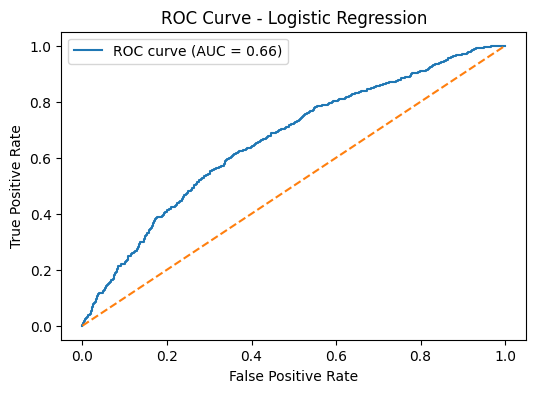

In [40]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label="ROC curve (AUC = {:.2f})".format(roc_auc))
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()